In [6]:
# Configuración inicial del entorno
import os
import json
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuración de matplotlib para mejores visualizaciones
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Definir la ruta base de los datos
BASE_PATH = "/home/victor/Desktop/Results/metrics_e3"  # Cambia esto si tu carpeta tiene otro nombre


In [7]:

# Verificar si la carpeta existe
if not os.path.exists(BASE_PATH):
    print(f"¡Advertencia! La carpeta '{BASE_PATH}' no existe.")
    print("Por favor, asegúrate de que:")
    print(f"1. El notebook esté en el directorio correcto")
    print(f"2. La carpeta '{BASE_PATH}' esté en el mismo directorio que el notebook")
    print(f"3. O cambia la variable BASE_PATH a la ruta correcta")
else:
    print(f"✓ Carpeta '{BASE_PATH}' encontrada")
    
    # Contar usuarios y archivos
    user_folders = glob.glob(os.path.join(BASE_PATH, "user_*"))
    print(f"✓ {len(user_folders)} carpetas de usuarios encontradas")
    
    # Contar archivos JSON
    json_files = glob.glob(os.path.join(BASE_PATH, "user_*", "round_*_training_history.json"))
    print(f"✓ {len(json_files)} archivos JSON encontrados")
    
    # Mostrar estructura de ejemplo
    if user_folders:
        print("\nEstructura de carpetas encontrada:")
        for user_folder in user_folders[:3]:  # Mostrar solo los primeros 3
            user_id = os.path.basename(user_folder)
            user_files = glob.glob(os.path.join(user_folder, "*.json"))
            print(f"  {user_id}: {len(user_files)} archivos")
        
        if len(user_folders) > 3:
            print(f"  ... y {len(user_folders) - 3} usuarios más")

✓ Carpeta '/home/victor/Desktop/Results/metrics_e3' encontrada
✓ 40 carpetas de usuarios encontradas
✓ 500 archivos JSON encontrados

Estructura de carpetas encontrada:
  user_15823: 17 archivos
  user_62690: 13 archivos
  user_3685: 10 archivos
  ... y 37 usuarios más


In [8]:
# Función para cargar todos los datos
def cargar_todos_los_datos(base_path=BASE_PATH):
    """
    Carga todos los archivos JSON de métricas en una estructura organizada
    """
    datos = {}
    
    # Buscar todas las carpetas de usuario
    user_folders = glob.glob(os.path.join(base_path, "user_*"))
    
    for user_folder in user_folders:
        user_id = os.path.basename(user_folder).replace("user_", "")
        
        # Buscar todos los archivos JSON de este usuario
        user_files = glob.glob(os.path.join(user_folder, "round_*_training_history.json"))
        
        datos_usuario = {}
        
        for file_path in sorted(user_files):  # Ordenados alfabéticamente
            # Extraer número de round del nombre del archivo
            filename = os.path.basename(file_path)
            round_num = filename.replace("round_", "").replace("_training_history.json", "")
            
            try:
                with open(file_path, 'r') as f:
                    contenido = json.load(f)
                datos_usuario[f"round_{round_num}"] = contenido
            except Exception as e:
                print(f"Error al cargar {file_path}: {e}")
        
        if datos_usuario:  # Solo añadir si hay datos
            datos[f"user_{user_id}"] = datos_usuario
    
    return datos

# Cargar los datos
print("Cargando datos...")
datos = cargar_todos_los_datos()
print(f"✓ Datos cargados para {len(datos)} usuarios")

Cargando datos...
✓ Datos cargados para 40 usuarios


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import glob

# Configuración de estilos
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [15, 10]
plt.rcParams['font.size'] = 12
sns.set_palette("husl")



Analizando métricas de la ronda mayor por usuario...
✓ Datos cargados para 40 usuarios
✓ Épocas analizadas en Actor Loss: 180
✓ Épocas analizadas en Critic Loss: 180
✓ Épocas analizadas en Train Rewards: 180

Calculando estadísticas...

RESUMEN ESTADÍSTICO

ACTOR LOSS:
  Rango por época: [-5.2470, -0.0199]
  Promedio global: -2.8376
  Variabilidad promedio (std): 0.3975

CRITIC LOSS:
  Rango por época: [0.0019, 0.0886]
  Promedio global: 0.0104
  Variabilidad promedio (std): 0.0029

TRAIN REWARDS:
  Rango por época: [0.5251, 0.9078]
  Promedio global: 0.7544
  Variabilidad promedio (std): 0.0567

CREANDO GRÁFICOS


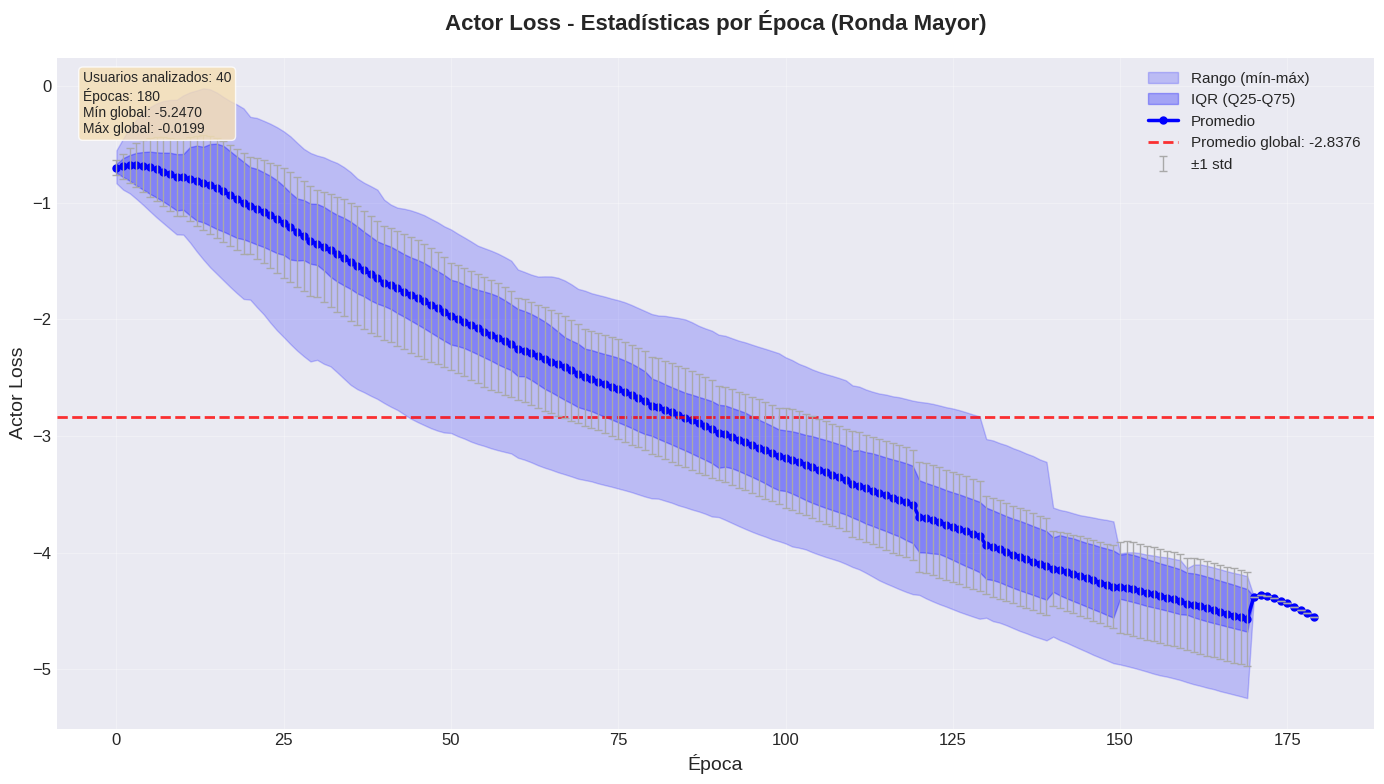

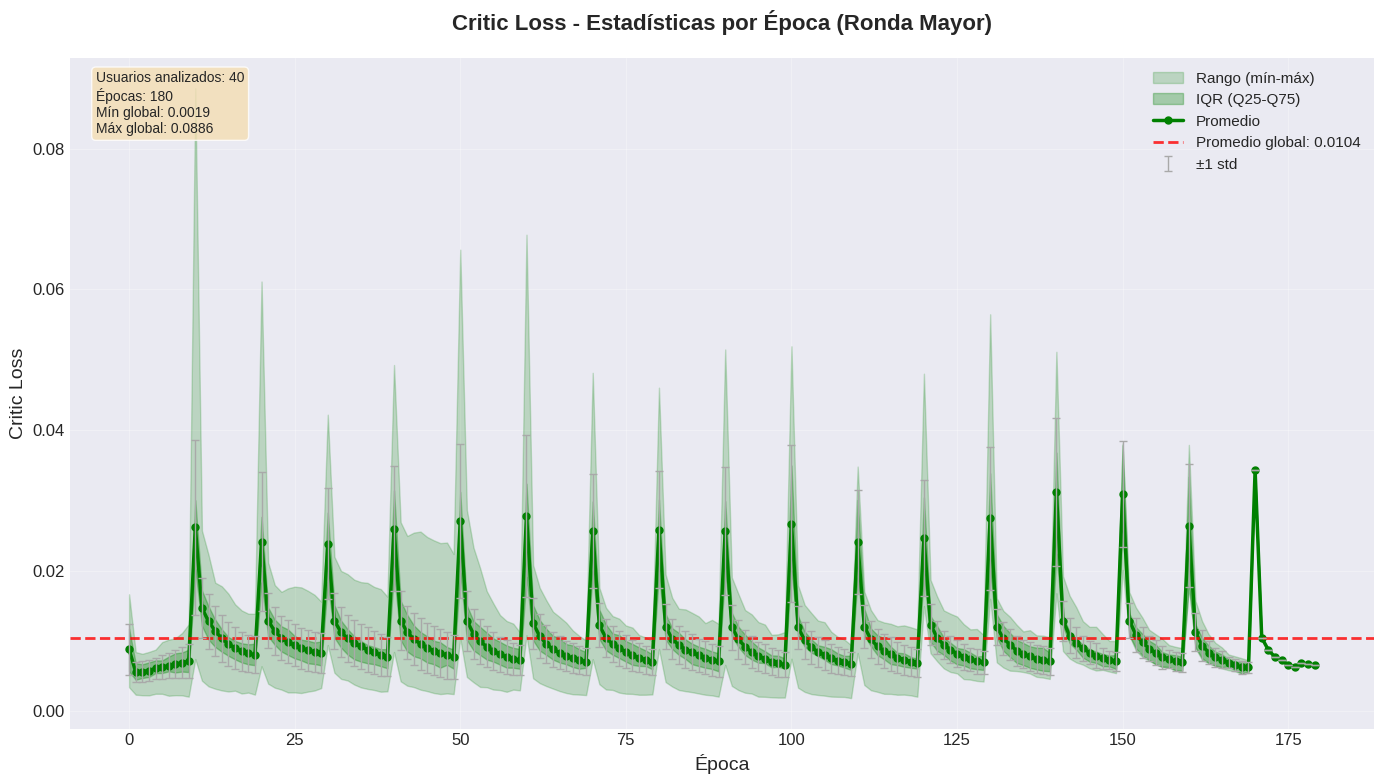

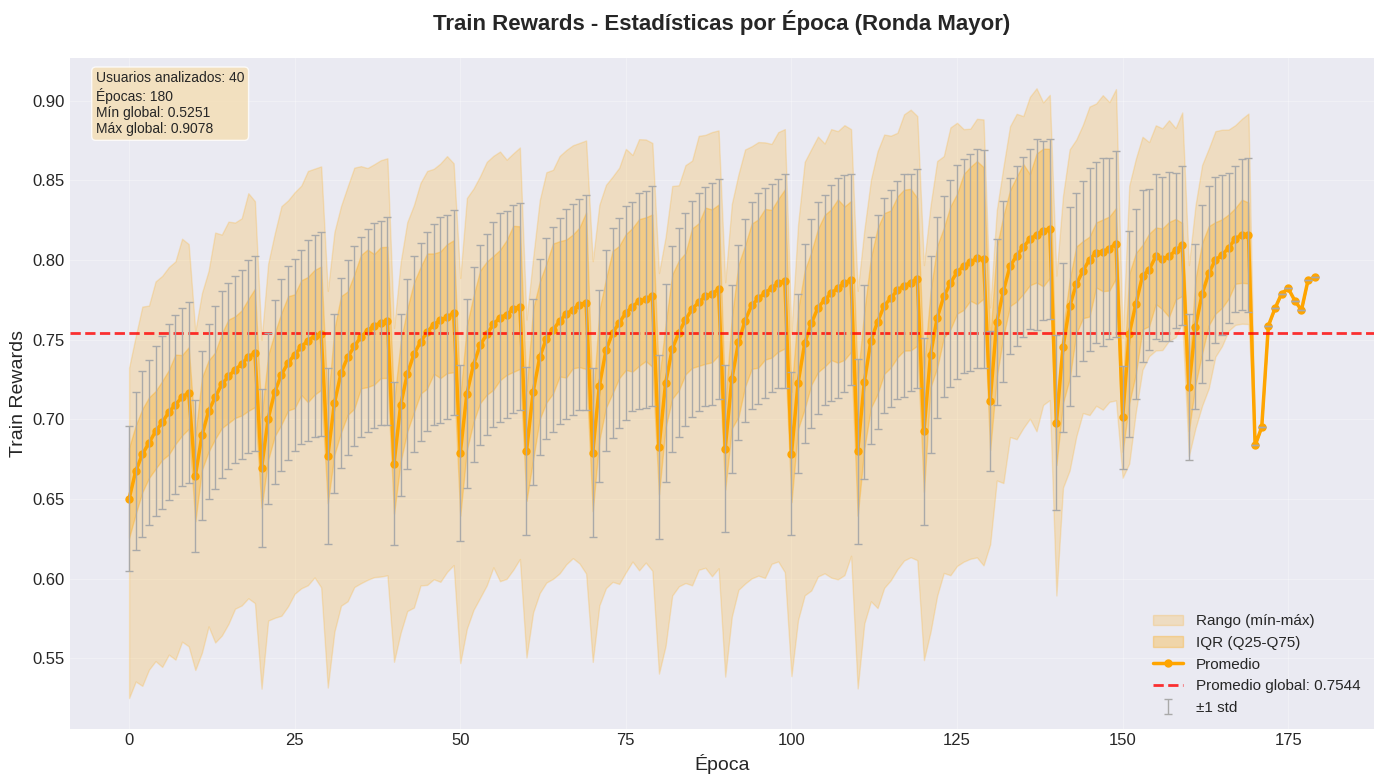

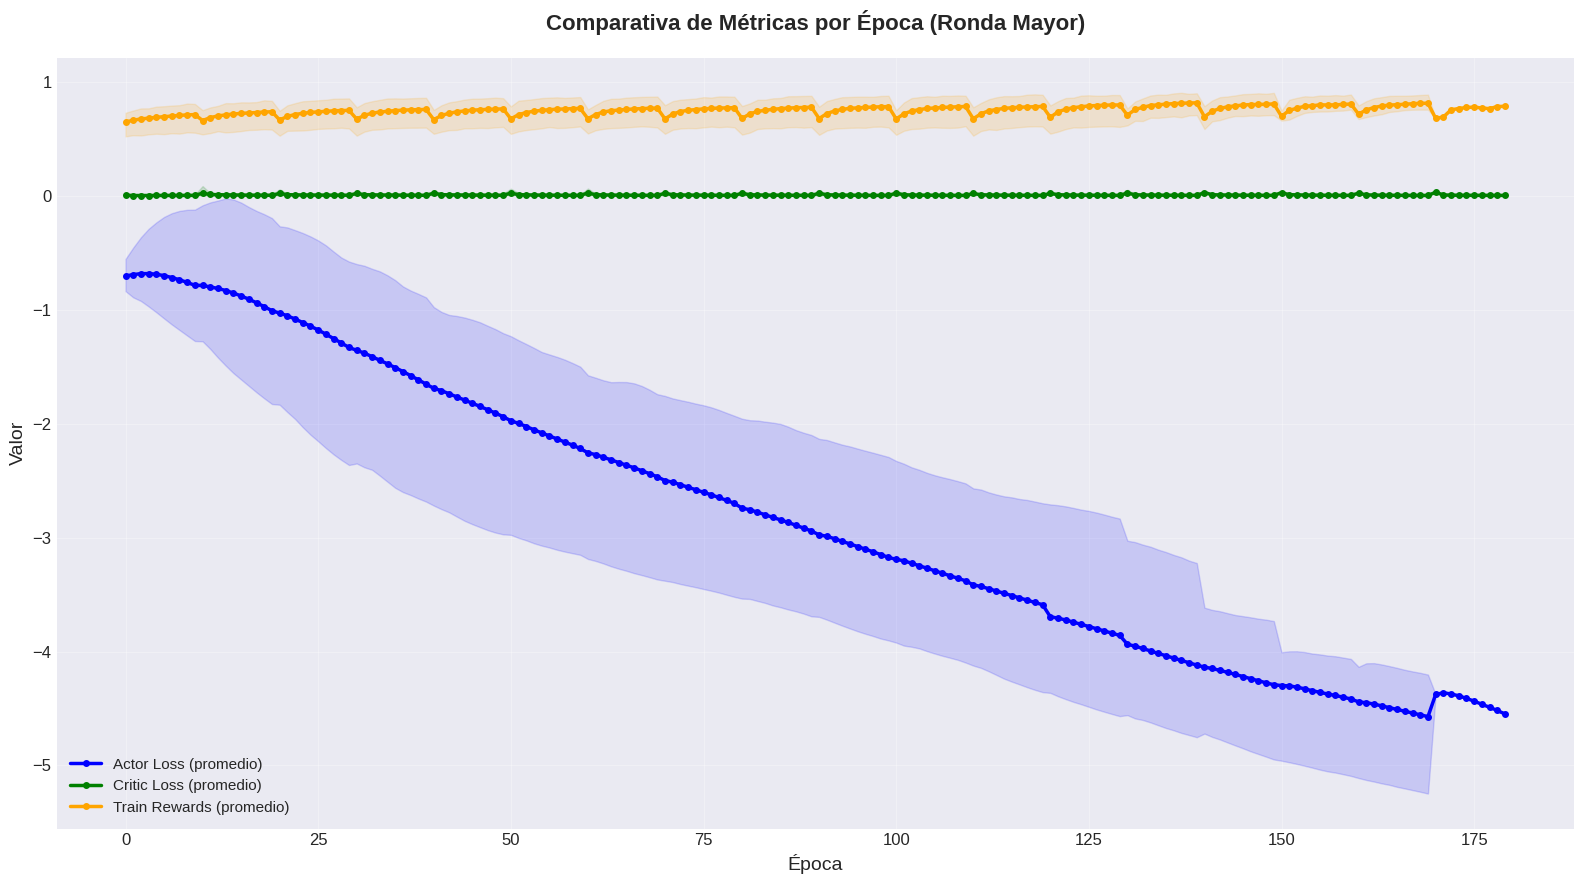


Generando dashboard completo...


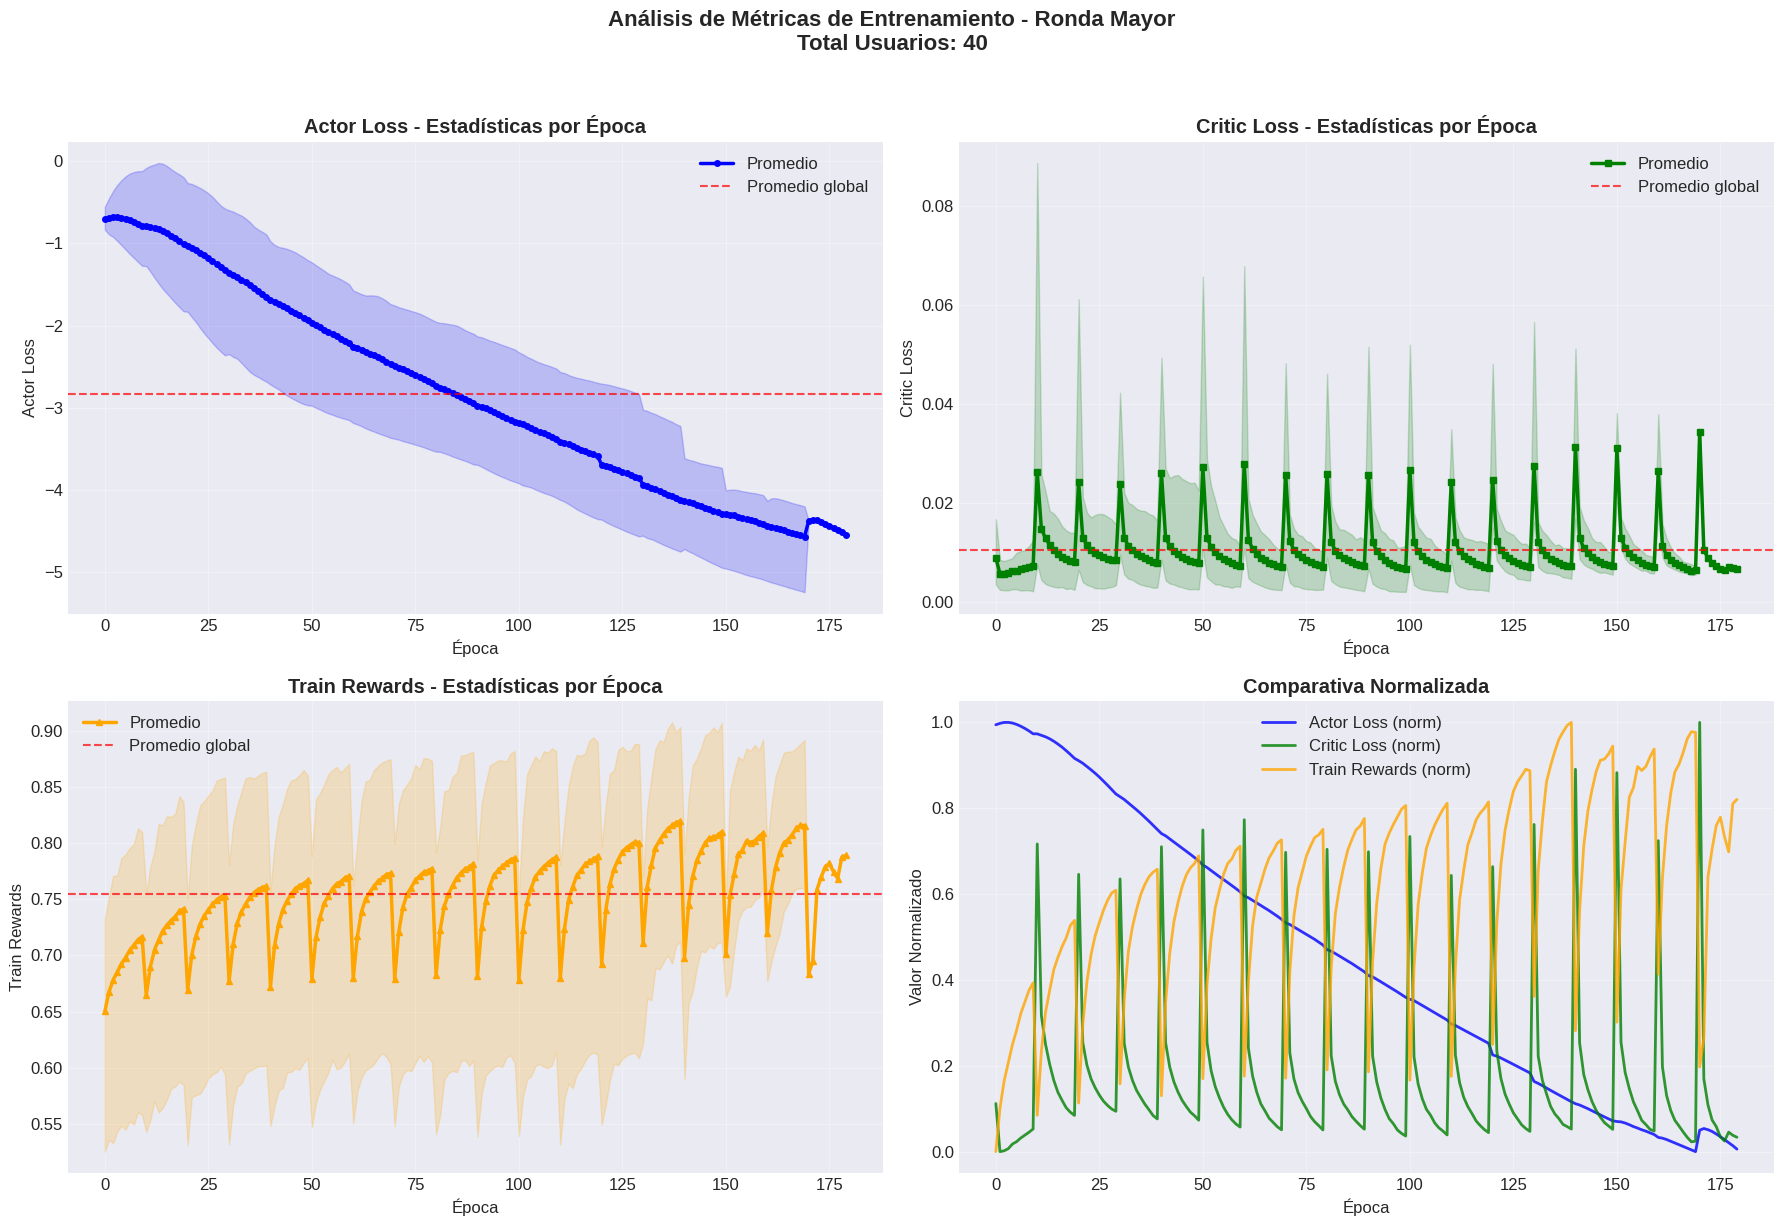

✓ Gráficos guardados en la carpeta 'graficos_metricas/'

DATAFRAME CON ESTADÍSTICAS
   Época  Actor_Loss_Avg  Actor_Loss_Min  Actor_Loss_Max  Critic_Loss_Avg  \
0      0       -0.701669       -0.834036       -0.551867         0.008817   
1      1       -0.688848       -0.888857       -0.451606         0.005603   
2      2       -0.680515       -0.920744       -0.360991         0.005658   
3      3       -0.680071       -0.968830       -0.286888         0.005802   
4      4       -0.685878       -1.019795       -0.230427         0.006108   

   Critic_Loss_Min  Critic_Loss_Max  Train_Rewards_Avg  Train_Rewards_Min  \
0         0.003429         0.016642           0.650173           0.525079   
1         0.002366         0.008426           0.667364           0.535506   
2         0.002290         0.008180           0.678034           0.532750   
3         0.002270         0.008444           0.685291           0.542896   
4         0.002498         0.008774           0.692412           0.5

In [10]:

def obtener_round_mayor_por_usuario(datos):
    """
    Encuentra la ronda mayor para cada usuario
    """
    rounds_mayores = {}
    
    for usuario, rounds in datos.items():
        round_nums = []
        for round_name in rounds.keys():
            # Extraer número del round
            try:
                num = int(round_name.replace('round_', ''))
                round_nums.append(num)
            except:
                continue
        
        if round_nums:
            round_mayor = max(round_nums)
            rounds_mayores[usuario] = f'round_{round_mayor}'
    
    return rounds_mayores

def extraer_metricas_round_mayor(datos):
    """
    Extrae las métricas de la ronda mayor de cada usuario
    """
    rounds_mayores = obtener_round_mayor_por_usuario(datos)
    
    # Diccionarios para almacenar métricas por época
    actor_loss_por_epoca = {}
    critic_loss_por_epoca = {}
    train_rewards_por_epoca = {}
    
    for usuario, round_mayor in rounds_mayores.items():
        if round_mayor in datos[usuario]:
            round_data = datos[usuario][round_mayor]
            
            # Extraer actor_loss
            if 'actor_loss' in round_data:
                for epoch, valor in enumerate(round_data['actor_loss']):
                    if epoch not in actor_loss_por_epoca:
                        actor_loss_por_epoca[epoch] = []
                    actor_loss_por_epoca[epoch].append(valor)
            
            # Extraer critic_loss
            if 'critic_loss' in round_data:
                for epoch, valor in enumerate(round_data['critic_loss']):
                    if epoch not in critic_loss_por_epoca:
                        critic_loss_por_epoca[epoch] = []
                    critic_loss_por_epoca[epoch].append(valor)
            
            # Extraer train_rewards
            if 'train_rewards' in round_data:
                for epoch, valor in enumerate(round_data['train_rewards']):
                    if epoch not in train_rewards_por_epoca:
                        train_rewards_por_epoca[epoch] = []
                    train_rewards_por_epoca[epoch].append(valor)
    
    return actor_loss_por_epoca, critic_loss_por_epoca, train_rewards_por_epoca

def calcular_estadisticas_por_epoca(metricas_por_epoca):
    """
    Calcula max, min, avg, std por época
    """
    estadisticas = {
        'epocas': [],
        'max': [],
        'min': [],
        'avg': [],
        'std': [],
        'q25': [],  # Percentil 25
        'q75': []   # Percentil 75
    }
    
    for epoca in sorted(metricas_por_epoca.keys()):
        valores = metricas_por_epoca[epoca]
        
        if valores:  # Solo si hay valores
            estadisticas['epocas'].append(epoca)
            estadisticas['max'].append(max(valores))
            estadisticas['min'].append(min(valores))
            estadisticas['avg'].append(np.mean(valores))
            estadisticas['std'].append(np.std(valores))
            estadisticas['q25'].append(np.percentile(valores, 25))
            estadisticas['q75'].append(np.percentile(valores, 75))
    
    return estadisticas

def crear_grafico_estadisticas(estadisticas, titulo, ylabel, color='blue', 
                               mostrar_std=True, mostrar_percentiles=True):
    """
    Crea un gráfico con estadísticas por época
    """
    fig, ax = plt.subplots(figsize=(14, 8))
    
    epocas = estadisticas['epocas']
    
    # 1. Área entre máximo y mínimo
    ax.fill_between(epocas, estadisticas['min'], estadisticas['max'], 
                    alpha=0.2, color=color, label='Rango (mín-máx)')
    
    # 2. Área entre percentiles 25 y 75 (opcional)
    if mostrar_percentiles and len(epocas) > 1:
        ax.fill_between(epocas, estadisticas['q25'], estadisticas['q75'], 
                        alpha=0.3, color=color, label='IQR (Q25-Q75)')
    
    # 3. Línea del promedio
    ax.plot(epocas, estadisticas['avg'], color=color, linewidth=2.5, 
            label='Promedio', marker='o', markersize=5)
    
    # 4. Línea punteada del promedio global
    avg_global = np.mean(estadisticas['avg'])
    ax.axhline(y=avg_global, color='red', linestyle='--', linewidth=2,
               label=f'Promedio global: {avg_global:.4f}', alpha=0.8)
    
    # 5. Barras de error para std (opcional)
    if mostrar_std and len(epocas) > 1:
        ax.errorbar(epocas, estadisticas['avg'], yerr=estadisticas['std'],
                   fmt='none', ecolor='darkgray', elinewidth=1, capsize=3,
                   label='±1 std')
    
    # Configurar gráfico
    ax.set_xlabel('Época', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Añadir texto informativo
    info_text = f'Usuarios analizados: {len(datos)}\n'
    info_text += f'Épocas: {len(epocas)}\n'
    info_text += f'Mín global: {min(estadisticas["min"]):.4f}\n'
    info_text += f'Máx global: {max(estadisticas["max"]):.4f}'
    
    ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    return fig, ax

def crear_grafico_comparativo(estadisticas_list, metricas_nombres, titulo, ylabel):
    """
    Crea un gráfico comparativo de múltiples métricas
    """
    fig, ax = plt.subplots(figsize=(16, 9))
    
    colores = ['blue', 'green', 'orange', 'purple', 'brown']
    
    for idx, (estadisticas, nombre) in enumerate(zip(estadisticas_list, metricas_nombres)):
        epocas = estadisticas['epocas']
        color = colores[idx % len(colores)]
        
        # Línea del promedio
        ax.plot(epocas, estadisticas['avg'], color=color, linewidth=2.5,
                label=f'{nombre} (promedio)', marker='o', markersize=4)
        
        # Área sombreada
        ax.fill_between(epocas, estadisticas['min'], estadisticas['max'],
                        alpha=0.15, color=color)
    
    ax.set_xlabel('Época', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

def crear_dashboard_completo(datos):
    """
    Crea un dashboard completo con todas las métricas
    """
    # Extraer métricas de la ronda mayor
    actor_loss_por_epoca, critic_loss_por_epoca, train_rewards_por_epoca = extraer_metricas_round_mayor(datos)
    
    # Calcular estadísticas
    stats_actor = calcular_estadisticas_por_epoca(actor_loss_por_epoca)
    stats_critic = calcular_estadisticas_por_epoca(critic_loss_por_epoca)
    stats_rewards = calcular_estadisticas_por_epoca(train_rewards_por_epoca)
    
    # Crear figura con subplots
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Actor Loss
    ax1 = plt.subplot(2, 2, 1)
    ax1.fill_between(stats_actor['epocas'], stats_actor['min'], stats_actor['max'], 
                     alpha=0.2, color='blue')
    ax1.plot(stats_actor['epocas'], stats_actor['avg'], color='blue', linewidth=2.5,
             label='Promedio', marker='o', markersize=4)
    ax1.axhline(y=np.mean(stats_actor['avg']), color='red', linestyle='--', 
                linewidth=1.5, alpha=0.7, label='Promedio global')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Actor Loss')
    ax1.set_title('Actor Loss - Estadísticas por Época', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Critic Loss
    ax2 = plt.subplot(2, 2, 2)
    ax2.fill_between(stats_critic['epocas'], stats_critic['min'], stats_critic['max'], 
                     alpha=0.2, color='green')
    ax2.plot(stats_critic['epocas'], stats_critic['avg'], color='green', linewidth=2.5,
             label='Promedio', marker='s', markersize=4)
    ax2.axhline(y=np.mean(stats_critic['avg']), color='red', linestyle='--', 
                linewidth=1.5, alpha=0.7, label='Promedio global')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Critic Loss')
    ax2.set_title('Critic Loss - Estadísticas por Época', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Train Rewards
    ax3 = plt.subplot(2, 2, 3)
    ax3.fill_between(stats_rewards['epocas'], stats_rewards['min'], stats_rewards['max'], 
                     alpha=0.2, color='orange')
    ax3.plot(stats_rewards['epocas'], stats_rewards['avg'], color='orange', linewidth=2.5,
             label='Promedio', marker='^', markersize=4)
    ax3.axhline(y=np.mean(stats_rewards['avg']), color='red', linestyle='--', 
                linewidth=1.5, alpha=0.7, label='Promedio global')
    ax3.set_xlabel('Época')
    ax3.set_ylabel('Train Rewards')
    ax3.set_title('Train Rewards - Estadísticas por Época', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Gráfico comparativo (todas las métricas juntas)
    ax4 = plt.subplot(2, 2, 4)
    
    # Normalizar para mejor visualización
    def normalizar_serie(serie):
        serie_norm = np.array(serie)
        return (serie_norm - serie_norm.min()) / (serie_norm.max() - serie_norm.min())
    
    ax4.plot(stats_actor['epocas'], normalizar_serie(stats_actor['avg']), 
             color='blue', linewidth=2, label='Actor Loss (norm)', alpha=0.8)
    ax4.plot(stats_critic['epocas'], normalizar_serie(stats_critic['avg']), 
             color='green', linewidth=2, label='Critic Loss (norm)', alpha=0.8)
    ax4.plot(stats_rewards['epocas'], normalizar_serie(stats_rewards['avg']), 
             color='orange', linewidth=2, label='Train Rewards (norm)', alpha=0.8)
    
    ax4.set_xlabel('Época')
    ax4.set_ylabel('Valor Normalizado')
    ax4.set_title('Comparativa Normalizada', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Título general
    fig.suptitle(f'Análisis de Métricas de Entrenamiento - Ronda Mayor\n'
                 f'Total Usuarios: {len(datos)}', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return fig

# --- EJECUCIÓN PRINCIPAL ---
print("Analizando métricas de la ronda mayor por usuario...")

# Cargar datos si no están cargados
if 'datos' not in locals() or not datos:
    datos = cargar_todos_los_datos(BASE_PATH)

if datos:
    print(f"✓ Datos cargados para {len(datos)} usuarios")
    
    # 1. Extraer métricas de la ronda mayor
    actor_loss_por_epoca, critic_loss_por_epoca, train_rewards_por_epoca = extraer_metricas_round_mayor(datos)
    
    print(f"✓ Épocas analizadas en Actor Loss: {len(actor_loss_por_epoca)}")
    print(f"✓ Épocas analizadas en Critic Loss: {len(critic_loss_por_epoca)}")
    print(f"✓ Épocas analizadas en Train Rewards: {len(train_rewards_por_epoca)}")
    
    # 2. Calcular estadísticas
    print("\nCalculando estadísticas...")
    stats_actor = calcular_estadisticas_por_epoca(actor_loss_por_epoca)
    stats_critic = calcular_estadisticas_por_epoca(critic_loss_por_epoca)
    stats_rewards = calcular_estadisticas_por_epoca(train_rewards_por_epoca)
    
    # 3. Mostrar resumen estadístico
    print("\n" + "="*60)
    print("RESUMEN ESTADÍSTICO")
    print("="*60)
    
    print("\nACTOR LOSS:")
    print(f"  Rango por época: [{min(stats_actor['min']):.4f}, {max(stats_actor['max']):.4f}]")
    print(f"  Promedio global: {np.mean(stats_actor['avg']):.4f}")
    print(f"  Variabilidad promedio (std): {np.mean(stats_actor['std']):.4f}")
    
    print("\nCRITIC LOSS:")
    print(f"  Rango por época: [{min(stats_critic['min']):.4f}, {max(stats_critic['max']):.4f}]")
    print(f"  Promedio global: {np.mean(stats_critic['avg']):.4f}")
    print(f"  Variabilidad promedio (std): {np.mean(stats_critic['std']):.4f}")
    
    print("\nTRAIN REWARDS:")
    print(f"  Rango por época: [{min(stats_rewards['min']):.4f}, {max(stats_rewards['max']):.4f}]")
    print(f"  Promedio global: {np.mean(stats_rewards['avg']):.4f}")
    print(f"  Variabilidad promedio (std): {np.mean(stats_rewards['std']):.4f}")
    
    # 4. Crear gráficos individuales
    print("\n" + "="*60)
    print("CREANDO GRÁFICOS")
    print("="*60)
    
    # Gráfico 1: Actor Loss
    fig1, ax1 = crear_grafico_estadisticas(
        stats_actor, 
        'Actor Loss - Estadísticas por Época (Ronda Mayor)',
        'Actor Loss',
        color='blue',
        mostrar_percentiles=True
    )
    plt.show()
    
    # Gráfico 2: Critic Loss
    fig2, ax2 = crear_grafico_estadisticas(
        stats_critic, 
        'Critic Loss - Estadísticas por Época (Ronda Mayor)',
        'Critic Loss',
        color='green',
        mostrar_percentiles=True
    )
    plt.show()
    
    # Gráfico 3: Train Rewards
    fig3, ax3 = crear_grafico_estadisticas(
        stats_rewards, 
        'Train Rewards - Estadísticas por Época (Ronda Mayor)',
        'Train Rewards',
        color='orange',
        mostrar_percentiles=True
    )
    plt.show()
    
    # 5. Gráfico comparativo
    fig4, ax4 = crear_grafico_comparativo(
        [stats_actor, stats_critic, stats_rewards],
        ['Actor Loss', 'Critic Loss', 'Train Rewards'],
        'Comparativa de Métricas por Época (Ronda Mayor)',
        'Valor'
    )
    plt.show()
    
    # 6. Dashboard completo
    print("\nGenerando dashboard completo...")
    fig_dashboard = crear_dashboard_completo(datos)
    plt.show()
    
    # 7. Opción para guardar los gráficos
    if True:
        import os
        os.makedirs('graficos_metricas', exist_ok=True)
        
        fig1.savefig('graficos_metricas/actor_loss_estadisticas.png', dpi=300, bbox_inches='tight')
        fig2.savefig('graficos_metricas/critic_loss_estadisticas.png', dpi=300, bbox_inches='tight')
        fig3.savefig('graficos_metricas/train_rewards_estadisticas.png', dpi=300, bbox_inches='tight')
        fig4.savefig('graficos_metricas/comparativa_metricas.png', dpi=300, bbox_inches='tight')
        fig_dashboard.savefig('graficos_metricas/dashboard_completo.png', dpi=300, bbox_inches='tight')
        
        print("✓ Gráficos guardados en la carpeta 'graficos_metricas/'")
    
    # 8. Crear DataFrame con estadísticas
    print("\n" + "="*60)
    print("DATAFRAME CON ESTADÍSTICAS")
    print("="*60)
    
    df_stats = pd.DataFrame({
        'Época': stats_actor['epocas'],
        'Actor_Loss_Avg': stats_actor['avg'],
        'Actor_Loss_Min': stats_actor['min'],
        'Actor_Loss_Max': stats_actor['max'],
        'Critic_Loss_Avg': stats_critic['avg'],
        'Critic_Loss_Min': stats_critic['min'],
        'Critic_Loss_Max': stats_critic['max'],
        'Train_Rewards_Avg': stats_rewards['avg'],
        'Train_Rewards_Min': stats_rewards['min'],
        'Train_Rewards_Max': stats_rewards['max']
    })
    
    print(df_stats.head())
    print(f"\nDimensiones del DataFrame: {df_stats.shape}")
    
    # 9. Guardar DataFrame a CSV
    guardar_csv = input("\n¿Deseas guardar las estadísticas a CSV? (s/n): ")
    if guardar_csv.lower() == 's':
        df_stats.to_csv('estadisticas_metricas_round_mayor.csv', index=False)
        print("✓ Estadísticas guardadas en 'estadisticas_metricas_round_mayor.csv'")
    
else:
    print("No se encontraron datos. Verifica la estructura de carpetas.")